## Script to print density onto a grid

Reads the basis set and molecular information from a Gaussian output file (can be modified as required) and density matrix from a given source (`.NPZ` file or any NumPy array), and then prints the matrix 

Include the keyword `GFInput` in the Gaussian input file's route section to print the basis set information.

In [1]:
import numpy as np
import scipy as sp
import sys
import os
import shutil
import matplotlib.pyplot as plt
import time
import re
from gauss_hf import *
from numba import jit

In [8]:
#====================
# CONVERSION FACTORS
#====================
# length: 1 bohr = 0.529177210903 angstroms
A0toANG = 0.529177
ANGtoA0 = 1/A0toANG

Build a `class` object for the set of basis functions

In [3]:
class basis:
    def __init__(self, pathLOG, pathFCHK):
        self.outfile = log_data(pathLOG)
        self.atoms, self.atomic_coords = self.outfile.get_molecule()
        self.outfchkfile = log_data(pathFCHK)
        self.NAOs = self.outfile.nao
        self.NAtoms = self.outfile.NAtoms
        # determine whether to use Cartesian or pure orbitals for "d" and "f" shells
        for (n, line) in enumerate(self.outfile.loglines):
            if ('Standard basis:' in line):
                elements = self.outfile.loglines[n].split()
                self.basis_set_label = elements[2]
                elements1 = list(elements[-2])
                elements2 = list(elements[-1])
                # print(elements1[1], elements2[0])
                if (elements1[1] == '5'):
                    self.d_cart = False
                elif (elements1[1] == '6'):
                    self.d_cart = True
                if (elements2[0] == '7'):
                    self.f_cart = False
                elif (elements2[0] == '10'):
                    self.f_cart = True
        # print(self.d_cart, self.f_cart)
        self.centers = []
        for i in range(self.NAtoms):
            self.centers.append(i+1)
        return
    #
    def build_shell(self, shell_label, n_prim, exps, coeffs, shell_center):
        assert exps.shape[0] == coeffs.shape[0], 'numbers of contraction coefficients and exponents listed for shell {} (belonging to center no. {}) are not the same!!'.format(shell_label, shell_center[0])
        assert exps.shape[0] == n_prim, 'number of exponents does not match the number of primitives listed for shell {} (belonging to center no. {})!'.format(shell_label, shell_center[0])
        shell = []
        # print('shell labelled {}'.format(shell_label))
        if (shell_label != 'SP'):
            if (shell_label == 'S'):
                shells = 1
                ang_mom = 0
            elif (shell_label == 'P'):
                shells = 3
                ang_mom = 1
            elif (shell_label == 'D'):
                if (self.d_cart == True):
                    shells = 6
                elif (self.d_cart == False):
                    shells = 5
                ang_mom = 2
            elif (shell_label == 'F'):
                if (self.f_cart == True):
                    shells = 10
                elif (self.f_cart == False):
                    shells = 7
                ang_mom = 3
            cgto_shell = {}
            cgto_shell['sub-shells'] = shells
            cgto_shell['ang. mom.'] = ang_mom
            cgto_shell['primitives'] = n_prim
            cgto_shell['alpha'] = exps
            cgto_shell['d'] = coeffs[:,0]
            cgto_shell['center'] = shell_center[0]
            cgto_shell['center coords'] = shell_center[1:]
            shell.append(cgto_shell)
        elif (shell_label == 'SP'):
            a, m = [1, 3], [0, 1]
            for b in a:
                cgto_shell = {}
                cgto_shell['sub-shells'] = b
                cgto_shell['ang. mom.'] = m[a.index(b)]
                cgto_shell['primitives'] = n_prim
                cgto_shell['alpha'] = exps
                cgto_shell['d'] = coeffs[:,a.index(b)]
                cgto_shell['center'] = shell_center[0]
                cgto_shell['center coords'] = shell_center[1:]
                shell.append(cgto_shell)
        return shell
    #
    def centers_to_shells(self):
        dict = {}
        for i in self.centers:
            dict[i] = 0
        for (n, line) in enumerate(self.outfchkfile.loglines):
            if ('Shell to atom map' in line):
                l = 1
                elements = []
                arr = ['Primitive', 'exponents']
                while (arr != elements[:2]):
                    elements = self.outfchkfile.loglines[n+l].split()
                    # print(elements)
                    if (arr != elements[:2]):
                        for j in elements:
                            k = int(float(j))
                            dict[k] += 1
                    else:
                        break
                    l += 1
        return dict
    #
    def build_basis(self):
        basis = []
        dict = self.centers_to_shells()
        coords = self.atomic_coords
        for (n, line) in enumerate(self.outfile.loglines):
            if ('AO basis set ' in line):
                shift = 0
                stars = 0
                try:
                    for k in range(self.NAtoms):
                        elements = self.outfile.loglines[n+1+k+shift].split()
                        # print('elements = ', elements)
                        center = int(float(elements[0]))
                        Rx, Ry, Rz = coords[center-1, 0], coords[center-1, 1], coords[center-1, 2]
                        shell_center = [center, Rx*ANGtoA0, Ry*ANGtoA0, Rz*ANGtoA0]
                        shift2 = 0
                        for i in range(dict[center]):
                            elements1 = self.outfile.loglines[n+1+k+shift+shift2+i+1].split()
                            shell_label = elements1[0]
                            # print('elements1 = ', elements1)
                            n_prim = int(float(elements1[1]))
                            # print('n_prim = {}'.format(n_prim))
                            scale_factor = float(elements1[2])
                            exps = np.zeros((n_prim), np.float64)
                            if (shell_label != 'SP'):
                                coeffs = np.zeros((n_prim,1), np.float64)
                            else:
                                coeffs = np.zeros((n_prim,2), np.float64)
                            for j in range(n_prim):
                                elements2 = self.outfile.loglines[n+1+k+shift+shift2+i+1+j+1].split()
                                # print('elements2 = ', elements2)
                                exps[j] = (scale_factor**2)*float(elements2[0])
                                coeffs[j,:] = elements2[1:]
                            fns = self.build_shell(shell_label, n_prim, exps, coeffs, shell_center)
                            for bas in fns:
                                basis.append(bas)
                            shift2 += n_prim
                        # print('i, j, k = {}, {}, {}'.format(i,j,k))
                        shift += shift2 + 1 + dict[center]
                except (IndexError, TypeError, ValueError) as e:
                    # raise(e)
                    break
        return basis

In [4]:
@jit
def basis_set_real(basis_set, xgrid, ygrid, zgrid):
    basfns = []
    xgrid, ygrid, zgrid = xgrid*ANGtoA0, ygrid*ANGtoA0, zgrid*ANGtoA0
    for cgto in basis_set:
        # only up to the d-shell (orb. ang. mom. 2) covered for now
        n_shells = cgto['sub-shells']
        exps = cgto['alpha']
        coeffs = cgto['d']
        ang_mom = cgto['ang. mom.']
        R = cgto['center coords']
        x, y, z = (xgrid - R[0]), (ygrid - R[1]), (zgrid - R[2])
        R2 = x**2 + y**2 + z**2
        assert len(exps) == len(coeffs), 'no. of contraction coeffs must be equal to the no. of exponents'
        if ang_mom == 0:
            prod_list = [1]
        elif ang_mom == 1:
            prod_list = [x, y, z]
        elif ang_mom == 2:
            if n_shells == 6:
                prod_list = [x*x, y*y, z*z, x*y, x*z, y*z]
            elif n_shells == 5:
                prod_list = [0.5*(2*z*z - x*x - y*y), (3**0.5)*x*z, (3**0.5)*y*z, 0.5*(3**0.5)*(x*x - y*y), (3**0.5)*x*y]
        rad_fn = 0
        for j in range(len(exps)):
            rad_fn += coeffs[j]*np.exp(-1*exps[j]*R2)
        for i in prod_list:
            fn = rad_fn*i
            # print(fn)
            basfns.append(fn)
    # print(basfns)
    return basfns

def density_real(dm, gridx, gridy, gridz, basis_set):
    Nx, Ny, Nz = len(gridx), len(gridy), len(gridz)
    density = np.zeros([Nx, Ny, Nz], np.complex128)
    for x in range(Nx):
        for y in range(Ny):
            for z in range(Nz):
                # print(x,y,z)
                basfns = basis_set_real(basis_set, gridx[x], gridy[y], gridz[z])
                # print(type(basfns))
                basfns = np.reshape(basfns, (1,len(basfns)))
                # print(basfns)
                density[x, y, z] = -1*np.sum(np.outer(basfns, basfns)*dm)
    return density

Function to produce a grid

In [5]:
def generate_grid(grid_pts, mesh_size, atomic_coords, geom_cent=True, x=None, y=None, z=None):
    Nx, Ny, Nz = grid_pts[0], grid_pts[1], grid_pts[2]
    dx, dy, dz = mesh_size[0], mesh_size[1], mesh_size[2]
    if (geom_cent == True):
        minx, maxx = np.amin(atomic_coords[:,0]), np.amax(atomic_coords[:,0])
        miny, maxy = np.amin(atomic_coords[:,1]), np.amax(atomic_coords[:,1])
        minz, maxz = np.amin(atomic_coords[:,2]), np.amax(atomic_coords[:,2])
        gcx, gcy, gcz = (minx + maxx)/2., (miny + maxy)/2., (minz + maxz)/2.
        gridx = np.arange(gcx - (Nx/2)*dx, gcx + (Nx/2)*dx, dx)
        gridy = np.arange(gcy - (Ny/2)*dy, gcy + (Ny/2)*dy, dy)
        gridz = np.arange(gcz - (Nz/2)*dz, gcz + (Nz/2)*dz, dz)
    else:
        minx = x
        miny = y
        minz = z
        gridx = np.arange(minx, (minx + Nx*dx), dx)
        gridy = np.arange(miny, (miny + Ny*dy), dy)
        gridz = np.arange(minz, (minz + Nz*dz), dz)
    return gridx, gridy, gridz

In [6]:
# bas = basis('./lih/hf_lih_6-31g.log', './lih/hf_lih_6-31g.fchk')
# bas = basis('./h2o/hf_h2o_6-31g.log', './h2o/hf_h2o_6-31g.fchk')
# bas = basis('./brcl/hf_brcl_6-31g.log', './brcl/hf_brcl_6-31g.fchk')
# bas = basis('./h2/hf_h2_sto-3g.log', './h2/hf_h2_sto-3g.fchk')
# bas = basis('./h/hf_h_sto-3g.log', './h/hf_h_sto-3g.fchk')
bas = basis('./h/hf_h_sto-3g_mod.log', './h/hf_h_sto-3g_mod.fchk')

basis_set = bas.build_basis()
# basis_set = []
# basis_set.append({'sub-shells': 1, 'ang. mom.': 0, 'primitives': 3, 'alpha': np.array([3.42525091, 0.62391373, 0.1688554]), 'd': np.array([0.2769343609526476, 0.2678388517525271, 0.0834736696169253]), 'center': 1, 'center coords': [0.0, 0.0, 0.7]})
# basis_set.append({'sub-shells': 1, 'ang. mom.': 0, 'primitives': 3, 'alpha': np.array([3.42525091, 0.62391373, 0.1688554]), 'd': np.array([0.2769343609526476, 0.2678388517525271, 0.0834736696169253]), 'center': 2, 'center coords': [0.0, 0.0, -0.7]})


Reading data from ./h/hf_h_sto-3g_mod.log...

Gaussian .LOG data read.


Reading data from ./h/hf_h_sto-3g_mod.fchk...

Text file may not as expected (expecting Gaussian .LOG file):
  "n_a", "n_b", "nao" instance variables will NOT be available.
  Further, only "get_matrix_lowtri_AO()" and "get_ee_onee_AO()"
  methods may be accessible without errors. Use "help()" method
  to get more information about this module.



In [7]:
basfns = 0
for i in basis_set:
    basfns += i['sub-shells']
    print(i)
print(basfns)
# print(basis_set)

{'sub-shells': 1, 'ang. mom.': 0, 'primitives': 3, 'alpha': array([3.42525091, 0.62391373, 0.1688554 ]), 'd': array([0.51224461, 0.49542068, 0.15440098]), 'center': 1, 'center coords': [0.0, 0.0, 0.0]}
1


In [9]:
# define grid-size and mesh-size (in angstroms)
grid_pts = [3, 3, 3]
# mesh_size = [0.073828*A0toANG, 0.073828*A0toANG, 0.073828*A0toANG]
mesh_size = [2.916225*A0toANG, 2.916225*A0toANG, 2.916225*A0toANG]

grid = generate_grid(grid_pts, mesh_size, bas.atomic_coords, geom_cent=False, x=-2.916225*A0toANG, y=-2.916225*A0toANG, z=-2.916225*A0toANG)

In [10]:
# log = log_data('./h2/hf_h2_sto-3g.log')
log = log_data('./h/hf_h_sto-3g_mod.log')
dm = log.get_density_AO()
print(dm)


Reading data from ./h/hf_h_sto-3g_mod.log...

Gaussian .LOG data read.

[[1.]]


In [11]:
# gridxy, gridz = np.array([0]), np.linspace(-3, 3, num=1000) 
density = density_real(dm, \
                    #    gridxy, gridxy, gridz, \
                       grid[0], grid[1], grid[2], \
                       basis_set
                      )

In [18]:
# for i in range(grid[2].size):
print(np.real(density)*2)

[[[-8.63877172e-06 -1.53087449e-04 -8.63877172e-06]
  [-1.53087449e-04 -3.07114038e-03 -1.53087449e-04]
  [-8.63877172e-06 -1.53087449e-04 -8.63877172e-06]]

 [[-1.53087449e-04 -3.07114038e-03 -1.53087449e-04]
  [-3.07114038e-03 -2.70079605e+00 -3.07114038e-03]
  [-1.53087449e-04 -3.07114038e-03 -1.53087449e-04]]

 [[-8.63877172e-06 -1.53087449e-04 -8.63877172e-06]
  [-1.53087449e-04 -3.07114038e-03 -1.53087449e-04]
  [-8.63877172e-06 -1.53087449e-04 -8.63877172e-06]]]


In [20]:
# np.savez('density_h2_sto-3g.npz', dens_data=density)
np.savez('density_h_sto-3g.npz', dens_data=density)

In [21]:
# dens_file = open('density_h2_sto-3g.txt', 'w')
# Nx, Ny, Nz = density.shape[0], density.shape[1], density.shape[2]
# for x in range(Nx):
#     for y in range(Ny):
#         for z in range(Nz):
#             dens_file.write('{}\t{}\t{}\t{}\n'.format(grid[0][x],grid[1][y],grid[2][z],np.real(density[x,y,z])))
# dens_file.close()

In [15]:
# print(len(basis_set))
# print(basis_set)
# print(grid)
# print(dm)
charge = np.sum(density)*(mesh_size[1]*mesh_size[0]*mesh_size[2]*(ANGtoA0**3))
print(charge)

(-33.74288638529156+0j)


In [23]:
dens1 = np.load('density_h_sto-3g_cube.npz', allow_pickle=True)['dens_data']
dens2 = np.load('density_h_sto-3g.npz', allow_pickle=True)['dens_data']
dens_diff = dens1 - dens2.real
# np.savez('densdiff_h2_sto-3g_cube-code.npz', densdiff_data=dens_diff)

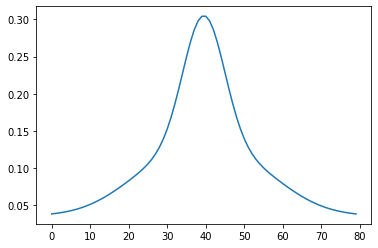

In [24]:
l = dens1[39,39,:]
o = dens2[39,39,:]
n = dens_diff[39,39,:]
k = l / o.real
m = n.shape[0]
# plt.plot(range(m),o)
# plt.plot(range(m),l)
plt.plot(range(m),k)
plt.show()